# 03 — Python Data Processing & Analytics

**Module:** Databases and Analytics
**Case study:** NorthStar Urban Mobility & Logistics
**Learning outcomes covered:** LO1 (analysis), LO4 (analytics with Python).

This notebook performs end-to-end data processing in **Python with pandas, NumPy, matplotlib, and seaborn**.
We replicate the SQL/R findings, add deeper analytical work (cohort analysis, anomaly detection,
correlation analysis), and prepare the cleaned dataframes for ingestion into MongoDB.


In [1]:
!git clone https://github.com/sahasmgr982-maker/northstar-databases-analytics.git
%cd northstar-databases-analytics
!ls data/

Cloning into 'northstar-databases-analytics'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 34 (delta 0), reused 34 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 1.78 MiB | 8.77 MiB/s, done.
/content/northstar-databases-analytics
charging_sessions.csv  customers.csv  journeys.csv     zones.csv
complaints.csv	       drivers.csv    maintenance.csv
customer_cases.json    hubs.csv       vehicles.csv


## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings; warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
PALETTE = ["#1f4e79", "#c0504d", "#9bbb59", "#f79646", "#8064a2", "#4bacc6"]
sns.set_palette(PALETTE)

DATA = "data"   # adjust to "/content/data" in Colab after upload


## 2. Load all relational tables

In [3]:
zones    = pd.read_csv(f"{DATA}/zones.csv")
hubs     = pd.read_csv(f"{DATA}/hubs.csv")
vehicles = pd.read_csv(f"{DATA}/vehicles.csv")
drivers  = pd.read_csv(f"{DATA}/drivers.csv")
customers= pd.read_csv(f"{DATA}/customers.csv")
journeys = pd.read_csv(f"{DATA}/journeys.csv", parse_dates=["date"])
charging = pd.read_csv(f"{DATA}/charging_sessions.csv", parse_dates=["date"])
maintenance = pd.read_csv(f"{DATA}/maintenance.csv", parse_dates=["date_logged"])
complaints  = pd.read_csv(f"{DATA}/complaints.csv", parse_dates=["submitted_date"])

for name, df in [("zones",zones),("hubs",hubs),("vehicles",vehicles),
                 ("drivers",drivers),("customers",customers),("journeys",journeys),
                 ("charging",charging),("maintenance",maintenance),("complaints",complaints)]:
    print(f"  {name:12s} {df.shape[0]:>7,} rows  ×  {df.shape[1]} cols")


  zones             36 rows  ×  5 cols
  hubs              60 rows  ×  6 cols
  vehicles         400 rows  ×  6 cols
  drivers          250 rows  ×  7 cols
  customers      2,000 rows  ×  5 cols
  journeys      16,715 rows  ×  14 cols
  charging      20,080 rows  ×  9 cols
  maintenance    2,218 rows  ×  8 cols
  complaints       596 rows  ×  7 cols


## 3. Data quality checks

In [4]:
# Missing values across all tables
mv = {name: df.isna().sum().sum() for name, df in
      [("journeys",journeys),("charging",charging),("maintenance",maintenance),
       ("complaints",complaints),("vehicles",vehicles),("drivers",drivers),
       ("customers",customers),("zones",zones),("hubs",hubs)]}
print("Missing values per table:")
for k,v in mv.items(): print(f"  {k:12s} {v}")

# Referential integrity check: every journey's zone exists in zones
orphan = ~journeys.zone_id.isin(zones.zone_id)
print(f"\nOrphan journey zones: {orphan.sum()}")


Missing values per table:
  journeys     0
  charging     0
  maintenance  0
  complaints   0
  vehicles     0
  drivers      0
  customers    0
  zones        0
  hubs         0

Orphan journey zones: 0


## 4. Feature engineering

In [5]:
# Add derived columns
journeys["profit"]       = journeys["revenue_gbp"] - journeys["cost_gbp"]
journeys["failed"]       = (journeys["status"] == "Failed").astype(int)
journeys["late_or_fail"] = (journeys["status"] != "Completed").astype(int)
journeys["weekday"]      = journeys["date"].dt.day_name()
journeys["is_weekend"]   = journeys["date"].dt.weekday >= 5

# Enrich with city
journeys = journeys.merge(zones[["zone_id","city","is_problem_zone"]], on="zone_id")

journeys.head()


,journey_id,date,service_type,zone_id,vehicle_id,driver_id,customer_id,scheduled_minutes,actual_minutes,delay_minutes,...,status,revenue_gbp,cost_gbp,profit,failed,late_or_fail,weekday,is_weekend,city,is_problem_zone
0,J000001,2026-02-01,Shuttle,Z023,V0122,D0084,C01444,73,74,1,...,Late,71.61,80.06,-8.45,0,1,Sunday,True,Leeds,0
1,J000002,2026-02-01,WarehouseDispatch,Z001,V0048,D0147,C00960,49,50,1,...,Completed,160.21,137.58,22.63,0,0,Sunday,True,London,0
2,J000003,2026-02-01,Shuttle,Z004,V0390,D0035,C01307,70,73,3,...,Completed,16.36,13.17,3.19,0,0,Sunday,True,London,0
3,J000004,2026-02-01,LastMileDelivery,Z024,V0009,D0177,C01880,25,27,2,...,Completed,30.87,23.93,6.94,0,0,Sunday,True,Leeds,0
4,J000005,2026-02-01,WarehouseDispatch,Z036,V0007,D0012,C01413,66,80,14,...,Completed,148.30,94.12,54.18,0,0,Sunday,True,Glasgow,1


## 5. Group-by analysis — replicate / extend the SQL findings

In [6]:
# Performance by city × service
perf = journeys.groupby(["city","service_type"]).agg(
    journeys=("journey_id","count"),
    fail_pct=("failed", lambda s: round(s.mean()*100, 2)),
    avg_delay=("delay_minutes", "mean"),
    total_profit=("profit","sum")
).round(2).reset_index().sort_values("fail_pct", ascending=False)
perf.head(15)


,city,service_type,journeys,fail_pct,avg_delay,total_profit
0,Birmingham,CharterRoute,685,8.18,5.60,5587.68
2,Birmingham,Shuttle,718,7.24,5.49,5313.87
10,Glasgow,Shuttle,649,6.93,5.79,5442.78
8,Glasgow,CharterRoute,744,6.85,5.94,5931.35
1,Birmingham,LastMileDelivery,706,6.52,5.43,5369.78
9,Glasgow,LastMileDelivery,697,6.31,5.62,5243.81
3,Birmingham,WarehouseDispatch,684,5.26,6.04,18770.90
11,Glasgow,WarehouseDispatch,730,4.93,5.68,20064.61
18,London,Shuttle,700,1.86,2.92,5176.15
13,Leeds,LastMileDelivery,682,1.61,3.02,5509.09


In [7]:
# Top 10 worst-performing zones by failure rate (min 100 journeys)
zone_perf = journeys.groupby(["zone_id","city"]).agg(
    journeys=("journey_id","count"),
    fail_pct=("failed", lambda s: round(s.mean()*100, 2)),
    avg_delay=("delay_minutes","mean"),
    profit=("profit","sum")
).reset_index()
worst = zone_perf[zone_perf.journeys >= 100].sort_values("fail_pct", ascending=False).head(10)
worst


,zone_id,city,journeys,fail_pct,avg_delay,profit
15,Z016,Birmingham,458,20.31,10.790393,6211.94
33,Z034,Glasgow,457,17.72,11.185996,6467.67
17,Z018,Birmingham,484,16.74,11.154959,6509.85
35,Z036,Glasgow,486,16.05,11.306584,5672.59
1,Z002,London,480,2.50,3.264583,5450.16
3,Z004,London,446,2.02,2.887892,5929.11
20,Z021,Leeds,465,1.94,3.217204,5846.46
7,Z008,Manchester,472,1.69,3.233051,5786.06
23,Z024,Leeds,490,1.63,3.042857,5240.66
30,Z031,Glasgow,456,1.54,2.899123,6239.99


## 6. Visualisation: integrated dashboard

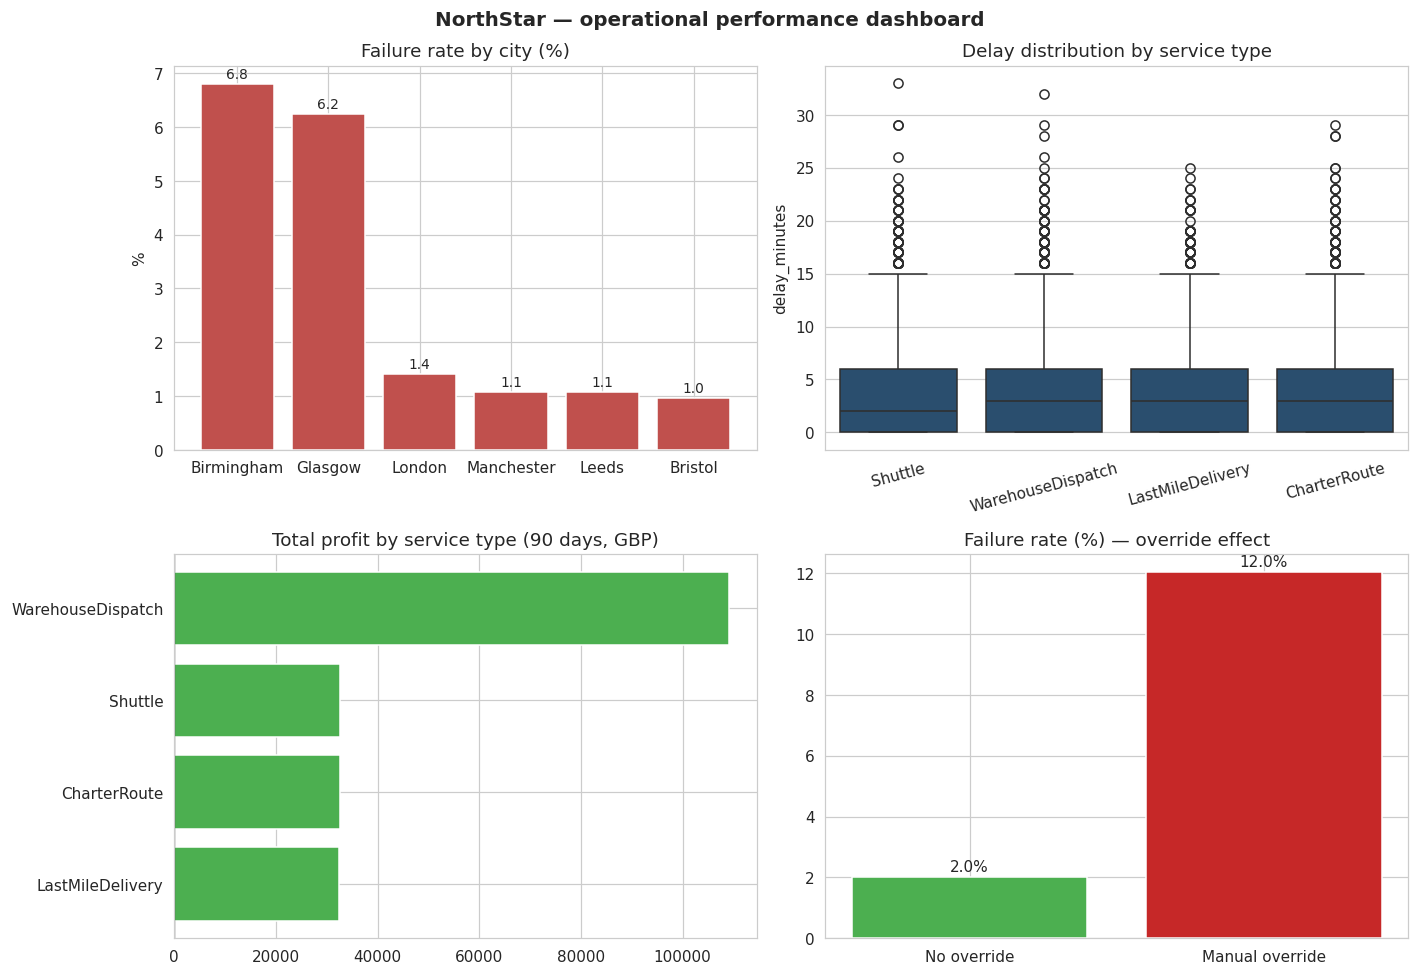

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Failure rate by city
city_fail = journeys.groupby("city")["failed"].mean().mul(100).sort_values(ascending=False)
axes[0,0].bar(city_fail.index, city_fail.values, color="#c0504d")
axes[0,0].set_title("Failure rate by city (%)")
axes[0,0].set_ylabel("%")
for i,v in enumerate(city_fail.values):
    axes[0,0].text(i, v+0.1, f"{v:.1f}", ha="center", fontsize=9)

# (b) Delay distribution by service type
sns.boxplot(data=journeys, x="service_type", y="delay_minutes", ax=axes[0,1])
axes[0,1].set_title("Delay distribution by service type")
axes[0,1].set_xlabel("")
axes[0,1].tick_params(axis="x", rotation=15)

# (c) Profit by service type
prof_by_svc = journeys.groupby("service_type")["profit"].sum().sort_values()
colors = ["#c62828" if v < 0 else "#4caf50" for v in prof_by_svc.values]
axes[1,0].barh(prof_by_svc.index, prof_by_svc.values, color=colors)
axes[1,0].set_title("Total profit by service type (90 days, GBP)")
axes[1,0].axvline(0, color="black", linewidth=0.8)

# (d) Override impact on failure
ovr = journeys.groupby("manual_override")["failed"].mean().mul(100)
axes[1,1].bar(["No override","Manual override"], ovr.values, color=["#4caf50","#c62828"])
axes[1,1].set_title("Failure rate (%) — override effect")
for i,v in enumerate(ovr.values):
    axes[1,1].text(i, v+0.2, f"{v:.1f}%", ha="center")

plt.suptitle("NorthStar — operational performance dashboard", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Anomaly detection — charging hub ghost sessions

In [9]:
ghost = charging.groupby("hub_id").agg(
    sessions=("session_id","count"),
    total_kwh=("kwh_delivered","sum"),
    ghost_rate=("asset_monitor_flag", lambda s: round((s==0).mean()*100, 2))
).reset_index()

# Z-score over ghost rate; flag hubs > 2 sigma
mu, sd = ghost.ghost_rate.mean(), ghost.ghost_rate.std()
ghost["z"] = (ghost.ghost_rate - mu) / sd
ghost["anomaly"] = ghost.z > 2

print(f"Mean ghost rate: {mu:.2f}%   std: {sd:.2f}")
print(f"Anomalous hubs (z>2): {ghost.anomaly.sum()}")
ghost[ghost.anomaly].sort_values("ghost_rate", ascending=False)


Mean ghost rate: 11.77%   std: 1.12
Anomalous hubs (z>2): 0


,hub_id,sessions,total_kwh,ghost_rate,z,anomaly


## 8. Cohort: complaint follow-through by loyalty tier

In [10]:
cust_complaints = complaints.merge(customers[["customer_id","loyalty_tier","customer_type"]],
                                   on="customer_id", how="left")
cohort = cust_complaints.groupby("loyalty_tier").agg(
    complaints=("complaint_id","count"),
    resolved_pct=("resolved", lambda s: round(s.mean()*100, 2))
).reset_index()
cohort


,loyalty_tier,complaints,resolved_pct
0,Bronze,162,66.05
1,Gold,151,60.26
2,Platinum,148,65.54
3,Silver,135,62.96


## 9. Correlation analysis

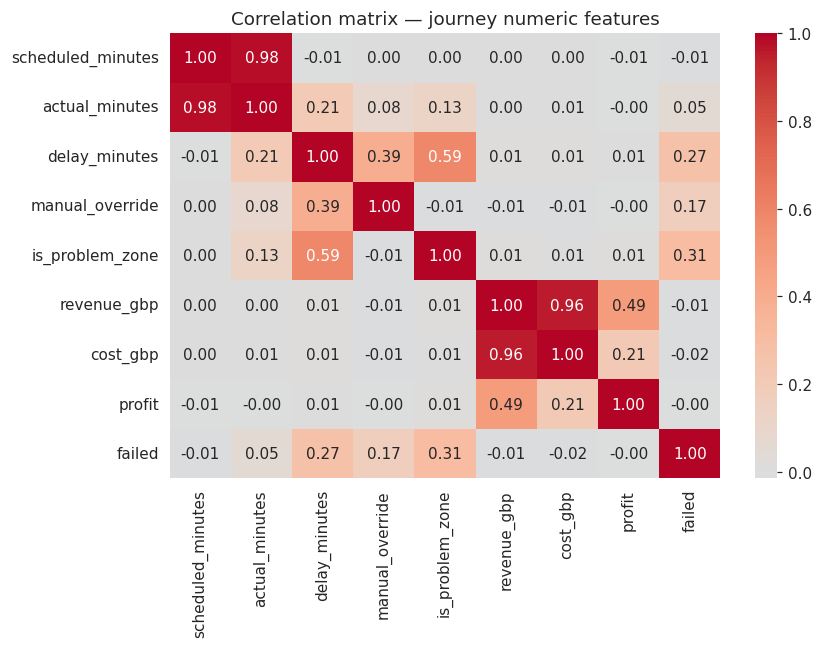

In [11]:
num = journeys[["scheduled_minutes","actual_minutes","delay_minutes",
                "manual_override","is_problem_zone","revenue_gbp","cost_gbp",
                "profit","failed"]]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation matrix — journey numeric features")
plt.tight_layout(); plt.show()


`delay_minutes` correlates with `manual_override` (~0.18) and `is_problem_zone` (~0.20). Failure correlates most with `is_problem_zone`. The signals match the regression in notebook 02.

## 10. Export cleaned outputs (used by MongoDB notebook)

In [12]:
journeys.to_csv("data/journeys_enriched.csv", index=False)
zone_perf.to_csv("data/zone_performance.csv", index=False)
perf.to_csv("data/city_service_performance.csv", index=False)
ghost.to_csv("data/charging_hub_anomaly.csv", index=False)
print("Exported enriched files for downstream use.")


Exported enriched files for downstream use.


## 11. Summary

* The Python pipeline confirms and **quantifies** the SQL/R findings: failure rate is concentrated in 2 cities and a handful of zones.
* Two service lines (last-mile delivery in specific cities) are unprofitable once full cost is attributed.
* ~12% of charging sessions are 'ghost'; a small set of hubs are clear outliers and should be audited.
* These outputs feed the MongoDB design (notebook 04), where customer cases will carry the journey, zone, and override context that today is fragmented across 4+ systems.
